[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shhommychon/my-blog-phuljite/blob/260814/jupyter/260814.ipynb)

# RGB Images in the Complex Chromaticity Plane

#### 예시 이미지 가져오기

In [1]:
from IPython.display import Audio, display
import librosa
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import skimage

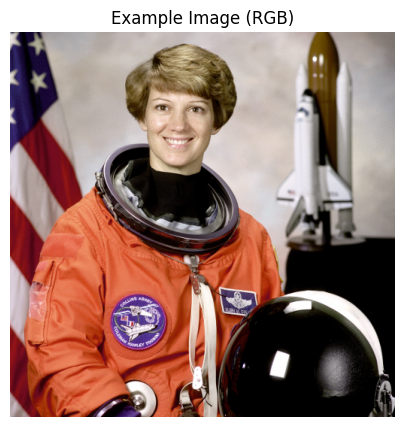

In [2]:
image = skimage.data.astronaut()

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Example Image (RGB)")
plt.axis("off")
plt.show()

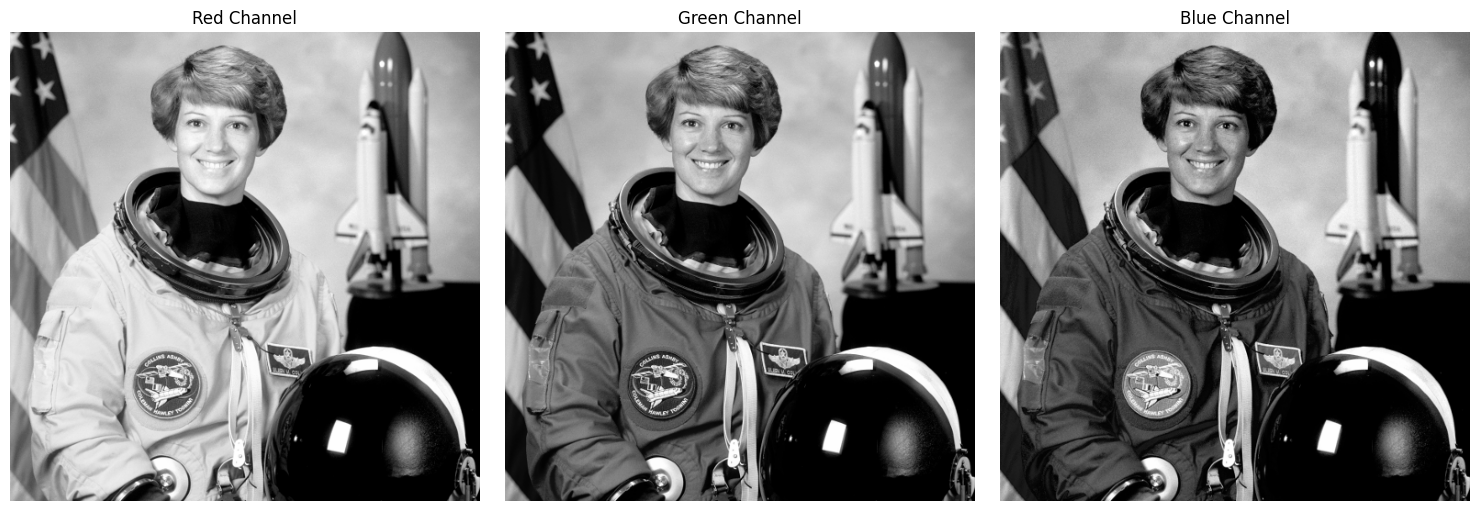

In [3]:
image_R = np.zeros_like(image)
image_G = np.zeros_like(image)
image_B = np.zeros_like(image)

image_R[:, :, 0] = image[:, :, 0]
image_R[:, :, 1] = image[:, :, 0]
image_R[:, :, 2] = image[:, :, 0]
image_G[:, :, 0] = image[:, :, 1]
image_G[:, :, 1] = image[:, :, 1]
image_G[:, :, 2] = image[:, :, 1]
image_B[:, :, 0] = image[:, :, 2]
image_B[:, :, 1] = image[:, :, 2]
image_B[:, :, 2] = image[:, :, 2]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_R)
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image_G)
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_B)
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

#### RGB를 complex chromaticity로 표현하기

이제부터 RGB를 $$I,\; Z=C e^{iH}$$로 표현해보고자 한다.

In [4]:
print(image.dtype)

R = image_R[:, :, 0].astype(np.float32) / 255.0
G = image_G[:, :, 1].astype(np.float32) / 255.0
B = image_B[:, :, 2].astype(np.float32) / 255.0

print(R.dtype, G.dtype, B.dtype)

uint8
float32 float32 float32


RGB 3차원에서 gray axis와 직교하는 2차원 chromatic plane을 복소평면의 real/imaginary 좌표로 표현하고자 한다.

RGB 공간에서 회색은 $(R,G,B)=(t,t,t)$, 즉 $(1,1,1)$ 방향이다.

이 회색축 방향의 평균 성분을 뽑으면 $I=\frac{R+G+B}{3}$.

따라서 RGB는 개념적으로 $$ (R,G,B) = \underbrace{(I,I,I)}_{\text{achromatic / brightness-like}} + \underbrace{(R-I,G-I,B-I)}_{\text{chromatic}} $$ 로 나눌 수 있다.



$I$가 물리적인 light intensity나 perceptual luminance는 아님을 주의.

정확히는 RGB 공간에서 **회색축 \((1,1,1)\) 방향으로 얼마나 가 있는가**를 나타내는 scalar라고 보면 된다(고 한다).

그래서:

- $I$가 크다 → 전체적으로 밝은 pixel
- $I$가 작다 → 전체적으로 어두운 pixel

In [5]:
I = (R + G + B) / 3.0

색 공간에서 R, G, B를 원 위에서 정확히 $ 120^\circ$씩 떨어뜨려 놓는다.

$$ R\rightarrow1, \quad G\rightarrow e^{i2\pi/3}, \quad B\rightarrow e^{-i2\pi/3} $$

그래서 $$ Z=R+Ge^{i2\pi/3}+Be^{-i2\pi/3} $$ 라고 정의한다.

In [6]:
w = np.exp(1j * 2*np.pi/3)

Z = R + (w * G) + (np.conj(w) * B)

In [7]:
# for dummy
assert np.isclose(
    np.exp(-1j * 2*np.pi/3),
    np.conj(w)
)

코드에서 `Z = R + (w * G) + (np.conj(w) * B)` 부분 자체가 회색축 성분을 자동으로 제거한다(고 한다).

이유는 $1+w+\bar w=0$이기 때문이다.

회색축 성분은 $(I,I,I)$이므로, 이를 $Z$에 넣으면
$$ I + wI + \bar w I = I(1+w+\bar w) = 0. $$
즉 **gray-axis 방향은 이 projection의 null space**이다(고 한다).


In [8]:
R2 = R - I
G2 = G - I
B2 = B - I

Z2 = R2 + (w * G2) + (np.conj(w) * B2)

assert np.isclose(Z, Z2).all()

복소수 $Z=x+iy$를 polar coordinate로 $$ Z=C e^{iH} $$라고 다시 쓸 수 있다.

여기서

$$
C=|Z|, \quad H=\arg Z
$$


이다.

이 중, 이 노트의 주 관심사인
$$
H
= \arg Z
= \text{atan2} \left(
  \sqrt{3}(G-B),\,
  2R-G-B
\right)
$$

형태의 polar angle은, RGB를 원형 chromatic plane에 투영해서 얻는 circular hue이며, 고전적인 [HSI 색상 공간](https://www.geeksforgeeks.org/electronics-engineering/what-is-hsi-color-space/)에서 사용되는 hue angle의 한 표현과 동치이다.

여기서, $C=|Z|$는 HSI/HSV의 saturation $S$와 같은 양이 아니다. $C$는 이 complex chromatic plane에서의 **chromatic magnitude**이며, RGB gray axis까지의 Euclidean distance $d_{\text{gray}}$와 $d_{\text{gray}}=\sqrt{\frac{2}{3}}\,C$의 관계를 가진다(고 한다). 따라서 $C$는 gray axis로부터의 거리에 "비례"한다고 보는 것이 정확하다.

그래서:
- $C = |Z|$가 크다 → 회색축에서 멀다 → 색이 강함
- $C = |Z|$가 작다 → 회색축에 가깝다 → 무채색에 가까움
- $H = arg(Z)$ → 그 색이 어느 방향인지, 즉 hue
- $C=|Z|=0$인 achromatic pixel에서는 $H=\arg Z$가 정의되지 않는다. 따라서 실제 계산에서는 $C$가 매우 작은 픽셀의 $H$는 의미가 없으며, 시각화나 후속 연산에서는 masking하는 것이 적절하다.


In [9]:
C = np.abs(Z)          # magnitude-like
H = np.angle(Z)        # phase-like: [-pi, pi]

# eps = 1e-8
# H[C < eps] = np.nan

반면 일반적으로 말하는 **HSV/HSB의 H**는 RGB cube를 hexcone으로 보고 `max(R,G,B)`와 `min(R,G,B)`에 따라 6개 구간으로 piecewise하게 계산한다(고 한다). 그래서 geometry가 원이 아니라 기본적으로 **육각형**이다(고 한다). \(출처: [위키백과](https://en.wikipedia.org/wiki/Hue#Defining_hue_in_terms_of_RGB)\) 참고로, circular RGB hue와 hexagonal HSV hue의 최대 차이는 대략 **1.2° 정도**이다(고 한다). \(출처: [위키백과](https://en.wikipedia.org/wiki/Hue#Defining_hue_in_terms_of_RGB)\)

##### 결과 살펴보기

In [10]:
def np_describe(x, name="array"):
    x = np.asarray(x)
    x_flat = x[np.isfinite(x)]

    print(f"{name}")
    print(f"  shape   : {x.shape}")
    print(f"  dtype   : {x.dtype}")
    print(f"  min     : {x_flat.min():.6f}")
    print(f"  1%      : {np.percentile(x_flat, 1):.6f}")
    print(f"  5%      : {np.percentile(x_flat, 5):.6f}")
    print(f"  25%     : {np.percentile(x_flat, 25):.6f}")
    print(f"  median  : {np.percentile(x_flat, 50):.6f}")
    print(f"  75%     : {np.percentile(x_flat, 75):.6f}")
    print(f"  95%     : {np.percentile(x_flat, 95):.6f}")
    print(f"  99%     : {np.percentile(x_flat, 99):.6f}")
    print(f"  max     : {x_flat.max():.6f}")
    print(f"  mean    : {x_flat.mean():.6f}")
    print(f"  std     : {x_flat.std():.6f}")


In [11]:
np_describe(I, "I")

I
  shape   : (512, 512)
  dtype   : float32
  min     : 0.000000
  1%      : 0.000000
  5%      : 0.000000
  25%     : 0.188235
  median  : 0.496732
  75%     : 0.703268
  95%     : 0.850980
  99%     : 0.973856
  max     : 1.000000
  mean    : 0.449408
  std     : 0.292325


In [12]:
np_describe(C, "C")

C
  shape   : (512, 512)
  dtype   : float64
  min     : 0.000000
  1%      : 0.000000
  5%      : 0.000000
  25%     : 0.027451
  median  : 0.064557
  75%     : 0.309357
  95%     : 0.560167
  99%     : 0.597663
  max     : 0.662954
  mean    : 0.176722
  std     : 0.202144


In [13]:
np_describe(H, "H")

H
  shape   : (512, 512)
  dtype   : float64
  min     : -3.040058
  1%      : -1.992860
  5%      : -1.653089
  25%     : 0.000000
  median  : 0.218842
  75%     : 0.408638
  95%     : 0.736814
  99%     : 1.047198
  max     : 3.141593
  mean    : 0.062328
  std     : 0.638705


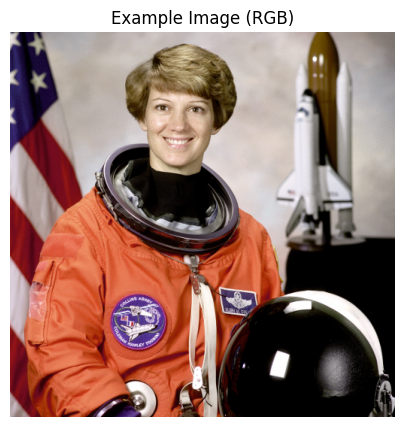

In [14]:
# once again
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Example Image (RGB)")
plt.axis("off")
plt.show()

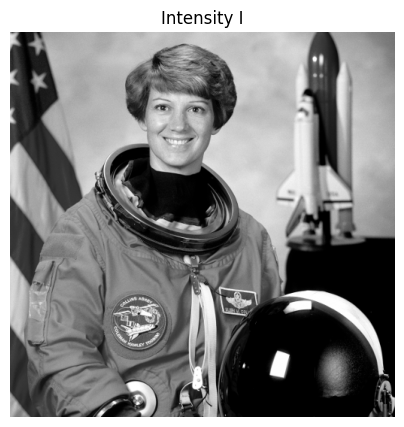

In [15]:
plt.figure(figsize=(5, 5))
plt.imshow(I, cmap="gray")
plt.title("Intensity I")
plt.axis("off")
plt.show()

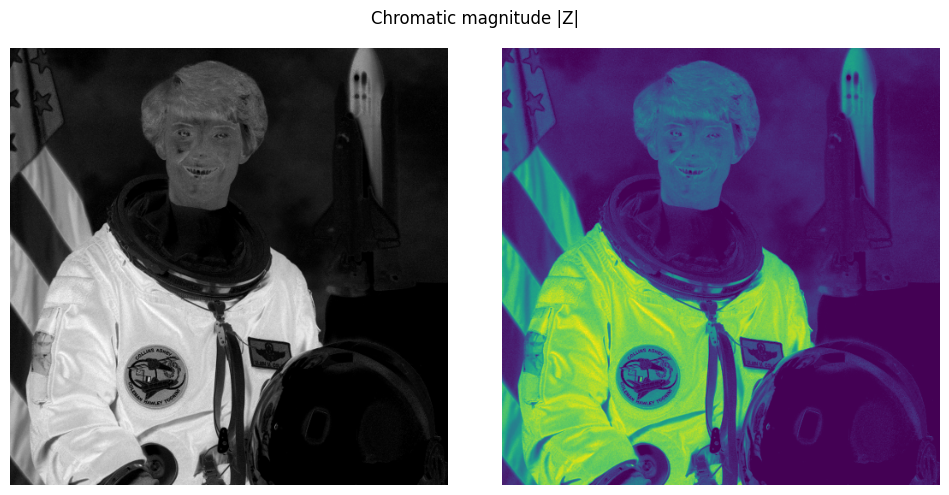

In [16]:
plt.figure(figsize=(10, 5))

plt.suptitle("Chromatic magnitude |Z|")

plt.subplot(1, 2, 1)
plt.imshow(C, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(C, cmap="viridis")
plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
HUE_CMAP = LinearSegmentedColormap.from_list(
    "standard_hue",
    [
        (0.00, "#ff0000"),  #   0° red
        (1/6,  "#ffff00"),  #  60° yellow
        (2/6,  "#00ff00"),  # 120° green
        (3/6,  "#00ffff"),  # 180° cyan
        (4/6,  "#0000ff"),  # 240° blue
        (5/6,  "#ff00ff"),  # 300° magenta
        (1.00, "#ff0000"),  # 360° red
    ],
    N=512,
)

def phase_to_hue_deg(phase):
    """
    phase [rad] -> hue angle [0, 360)

    0       ->   0° red
    pi/3    ->  60° yellow
    2pi/3   -> 120° green
    pi      -> 180° cyan
    -2pi/3  -> 240° blue
    -pi/3   -> 300° magenta
    """
    return np.degrees(np.asarray(phase)) % 360.0

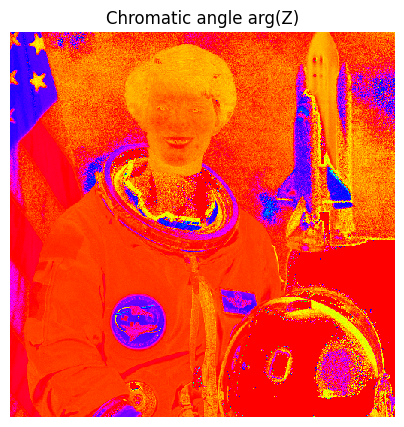

In [18]:
H_deg = phase_to_hue_deg(H)

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(
    H_deg,
    cmap=HUE_CMAP,
    vmin=0,
    vmax=360,
    interpolation="nearest",
)
ax.set_title("Chromatic angle arg(Z)")
ax.axis("off")

plt.show()

In [19]:
def phase_to_hue_deg(phase):
    return np.degrees(np.asarray(phase)) % 360.0


def normalize_01(x, pmin=1, pmax=99, eps=1e-8):
    """
    robust normalization to [0,1]
    """
    x = np.asarray(x, dtype=np.float32)
    lo = np.percentile(x, pmin)
    hi = np.percentile(x, pmax)
    x = (x - lo) / (hi - lo + eps)
    return np.clip(x, 0.0, 1.0)


def hue_rgba_from_phase_and_mask(H, mask, HUE_CMAP, mask_is_already_01=False):
    """
    H    : phase in radians [-pi, pi]
    mask : alpha mask, white(1) -> opaque / black(0) -> transparent
    """
    H_deg = phase_to_hue_deg(H)
    pos = H_deg / 360.0

    # hue colormap -> RGB
    hue_rgb = HUE_CMAP(pos)[..., :3]

    # alpha
    if mask_is_already_01:
        alpha = np.clip(mask, 0.0, 1.0)
    else:
        alpha = normalize_01(mask)

    rgba = np.dstack([hue_rgb, alpha])
    return rgba

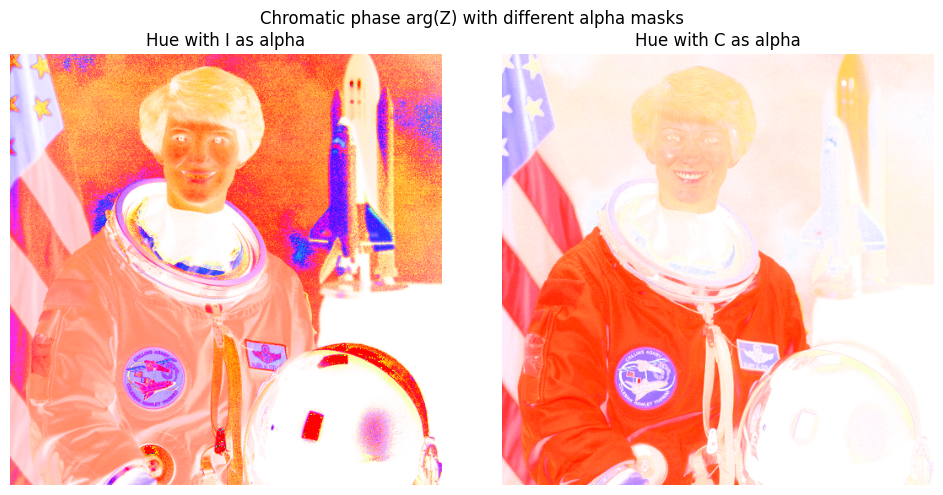

In [20]:
rgba_I = hue_rgba_from_phase_and_mask(
    H, I, HUE_CMAP, mask_is_already_01=True   # I가 이미 [0,1]이므로 True
)

rgba_C = hue_rgba_from_phase_and_mask(
    H, C, HUE_CMAP, mask_is_already_01=False  # C는 보통 robust normalize 권장
)

plt.figure(figsize=(10, 5))
plt.suptitle("Chromatic phase arg(Z) with different alpha masks")

plt.subplot(1, 2, 1)
plt.imshow(rgba_I)
plt.title("Hue with I as alpha")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rgba_C)
plt.title("Hue with C as alpha")
plt.axis("off")

plt.tight_layout()
plt.show()

#### 진짜 개뻘짓 : 아무 의미 없는 sonification

In [21]:
image.shape, Z.shape, np.rot90(Z.T).shape

((512, 512, 3), (512, 512), (512, 512))

In [22]:
sr = 16000
hop_length = 128

In [23]:
D = C * np.exp(1j * H) # = Z

y = librosa.istft(
    np.rot90(D.T),
    hop_length=hop_length,
    center=True,
)

# 청취용 정규화
y = y / (np.max(np.abs(y)) + 1e-12) * 0.8

display(Audio(y, rate=sr))

In [24]:
D2 = I * np.exp(1j * H)

y2 = librosa.istft(
    np.rot90(D2.T),
    hop_length=hop_length,
    center=True,
)

# 청취용 정규화
y2 = y2 / (np.max(np.abs(y2)) + 1e-12) * 0.8

display(Audio(y2, rate=sr))